# DEF-D Fysieke Ontwerpopdracht 1 invul template

## Groepsgegevens en planning 

Aan het einde van deze ontwerpopdracht lever je als groep dit notebook gezamenlijk in via een pull request op Github en lever je een link naar dit pull request in op Brightspace. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan. Werk in de juiste branch.

| Groep: 35     |  |
| :-------------|:-------------|
| Student Pascal van de Beek| Student Studienummer ** |
| Student Koen Gerkes| Student Studienummer 6495311 |
| Student Jesse Langenberg| Student Studienummer 6290116 |

| Planning Groep: 35     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1: Criteria opgesteld | 12:00 |
| Mijlpaal 2: Eerste kalibratie meting gedaan| 14:00 |
| Mijlpaal 3: Alle leerdoelen bereikt| 16:30|
| Mijlpaal 4: Alles inleveren en controleren| 17:30| 
| Pauze 1| 12:30-13:30 |
| Pauze 2| 15:00-15:15 |

## *Opdracht 1*: Foto van alle schetsen.

Zet de foto in dezelfde map als dit notebook en verander hieronder de naam in de naam van de foto.

![Alt](fotosketch.jpg "analyse: ideeen")

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Krachtsensor | Kleine 'parkeerplaats'-sensor | Kan meten of een gewichtje met range tussen 5 en 50 gram op een plek met oppervlakte 1.5-3.0cm^2.  De meting moet zich elke minuut herhalen om te checken of het gewichtje nog op de plek ligt. Het lampje gaat aan als het gewichtje op de krachtmeter ligt. |
|Lichtsensor | Lichtsensor om te meten of het ergens donker is, dan een lampje aanzetten | Als de lichtintensiteit onder de 2500 lux komt, met foutmarge van 50 lux, gaat er een lamp aan, de lamp moet aan blijven staan voor 5 minuten. De sensor doet om de 5 minuten een nieuwe meting. |
|Thermosensor | Soort thermometer om te meten hoe warm het is, dan lampje aan | Als de temperatuur onder de 16 graden Celsius komt, gaat er een rood lampje aan (zodat je weet dat de verwarming aan moet), boven de 22 graden Celsius gaat het lampje uit, het lampje moet gedurende 1 minuut aan blijven staan. Er moet een groen lampje aangaan als het boven de 27 graden Celsius is. |

Groep 35 heeft gekozen voor krachtsensor. 

## *Opdracht 3*: Foto van de schets van jouw meetopstelling in.
Licht kort toe wat er in de foto te zien is.
 ![Alt](Schematischetekening.jpg "schets student")
 


 ![Alt](Schema.png "schets student")

 De bovenste afbeelding geeft de volledige opstelling weer waarmee wij willen gaan meten. De afbeelding daaronder geeft het circuit tussen breadboard en Arduino schematisch weer. De weerstanden die gebruikt worden zijn: bij het lampje een weerstand van 10000 Ohm, en die van de krachtsensor heeft ook een weerstand van 10000 Ohm.






## *Opdracht 4*: Beantwoord de vragen

1. Welke variabelen ga je veranderen? De massa van het object op de krachtsensor, de tijd dat het lampje aanstaat.
2. Over welk bereik ga je deze variabelen veranderen? De massa van het object variëren we van 0 tot ~ 60 gram. De tijd dat het lampje aanstaat, variëren we van 2 seconde tot 5 seconde.
3. Wat ga je allemaal meten? De kracht van het object op de krachtsensor door de zwaartekracht te meten van een batterij, verschillende magneetjes.
4. Hoeveel metingen ga je doen? 10
5. Ga je met deze keuzes kunnen evalueren of jouw sensor geschikt is voor de gekozen toepassingen? Ja, als de metingen zeer nauwkeurig gedaan kunnen worden.


## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
Licht kort toe wat er in de foto te zien is.
 ![Alt](Opstelling.jpg "meetopstelling student")


We zien de opstelling, met de arduino, het breadboard en de krachtsensor. We zetten (bijvoorbeeld) de batterij op 2 kleine magneetjes op de krachtsensor om een meting uit te kunnen voeren. Als basis waar we alle andere magneetjes/items opzetten, gebruiken we 2 kleine magneetjes. Dit doen we omdat de krachtsensor anders niet goed werkt: het oppervlak van de krachtsensor mag maar op een klein gedeelte ingedrukt zijn, vandaar de 2 kleine magneetjes als basisondergrond.

## *Opdracht 6*: Meten en fitten, Leerdoel

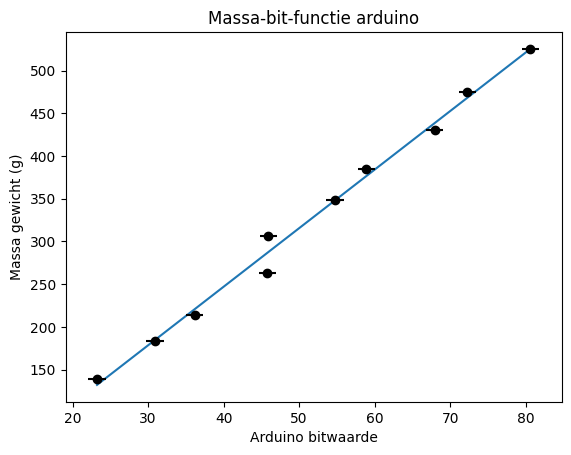

De waarde van a in de formule y = a*x+b is:  6.86 de waarde van b is:  -27.22


In [32]:
# Zet hier jouw data in een voor jou handig formaat
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt




#kalibratie-waarde van batterij met 2 magneetjes erbij: 350
#de waarde met 0 in de eerste (gecommente) arduino data, komt omdat het gewicht op de krachtmeter te licht is voor de krachtmeter, dus die kunnen we niet gebruiken
#arduino_data = np.array([350, 402, 206, 0, 0, 151, 0])


#Data voor onzekerheid
data_arduino_onz = np.array([545,552,550,544,548,551,549,555,552,556])

sigma = np.std(data_arduino_onz)
N = len(data_arduino_onz)
onz = sigma/np.sqrt(N)

#data
#arduino_data = np.array([151, 206, 253, 308, 350, 374, 402]) 
#massa_data = np.array([25.13, 31.79, 35.27, 42.60, 48.92, 53.86, 59.72])

#nieuwe metingen data
arduino_data = np.array([139, 184, 214, 263, 306, 348, 385, 430, 475, 525])
massa_data = np.array([23.24, 30.89, 36.17, 45.8, 45.92, 54.76, 58.92, 67.95, 72.27, 80.61])

#fitfunctie
def fit_func(x, a, b):
    return a*x + b

popt, pcov = curve_fit(fit_func,massa_data,arduino_data)
a_fit, b_fit = popt

#fitten
x_fit = np.linspace(min(massa_data), max(massa_data), 100)
y_fit = fit_func(x_fit, a_fit, b_fit)


#plotten
plt.plot(x_fit,y_fit, label='Curvefit: y=a*x+b')
plt.plot(massa_data, arduino_data, '.')
plt.errorbar(massa_data, arduino_data, xerr=onz, fmt = 'ko', label='Meetgegevens met onzekerheid')
plt.title("Massa-bit-functie arduino")
plt.ylabel("Massa gewicht (g)")
plt.xlabel("Arduino bitwaarde")
plt.show()

#gevonden waardes
print("De waarde van a in de formule y = a*x+b is: ", round(a_fit,2), "de waarde van b is: ",round(b_fit,2))

## *Opdracht 7*: Iteratie nodig?

#Ja, er is zeker iteratie nodig, want we hebben gemerkt dat bepaalde massa's (namelijk m<20 gram) geen juiste waarde aangaven op de arduino (ze gaven de waarde 0 terug, terwijl er zeker wel een kracht op de krachtmeter werkt). Daarom hebben we ervoor gekozen om meer metingen met hogere gewichten te doen, zodat de waarden die de arduino aangeeft wel accuraat zijn. Ook hebben we de opstelling gewijzigd: we hebben ervoor gezorgd, met behulp van extra verlengdraadjes, dat de krachtmeter wat verder van het breadboard aangesloten is. Hierdoor kunnen we nauwkeuriger meten, omdat de meetopstelling nu stabieler is en er niks in de weg zit om een meting te doen.


Foto nieuwe opstelling:
![Alt](Verbeterdeopstelling.jpg "meetopstelling student")






In opdracht 6 staat eerst uitgecomment de eerste metingen, daarna staan de nieuwe metingen, waarbij we de verbeterde opstelling gebruikt hebben.



## *Opdracht 8*: Conclusie, leerdoel

Na het uitvoeren van de metingen kunnen we concluderen dat met de nieuwe meetopstelling we meer accuraat kunnen meten. Echter kan er nog wel verbetering komen: de opstelling is nog steeds instabiel waardoor metingen verstoord zouden kunnen worden. Daarom is de sensor nog niet goed bruikbaar voor onze toepassing.

## *Opdracht 9*: Aantonen leerdoelen beheersing

Om aan te tonen dat je de leerdoelen beheerst, kopieer je hieronder alle cellen met 'leerdoel' in de titel. Zet zelf de cellen onder de goede kopjes. Mogelijk komt een cel bij meerdere leerdoelen terug.

### Leerdoel 1: Simpele circuits (RC-circuit, spanningsdelers met sensoren) ontwerpen en fabriceren.

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Krachtsensor | Kleine 'parkeerplaats'-sensor | Kan meten of een gewichtje met range tussen 5 en 50 gram op een plek met oppervlakte 1.5-3.0cm^2.  De meting moet zich elke minuut herhalen om te checken of het gewichtje nog op de plek ligt. Het lampje gaat aan als het gewichtje op de krachtmeter ligt. |
|Lichtsensor | Lichtsensor om te meten of het ergens donker is, dan een lampje aanzetten | Als de lichtintensiteit onder de 2500 lux komt, met foutmarge van 50 lux, gaat er een lamp aan, de lamp moet aan blijven staan voor 5 minuten. De sensor doet om de 5 minuten een nieuwe meting. |
|Thermosensor | Soort thermometer om te meten hoe warm het is, dan lampje aan | Als de temperatuur onder de 16 graden Celsius komt, gaat er een rood lampje aan (zodat je weet dat de verwarming aan moet), boven de 22 graden Celsius gaat het lampje uit, het lampje moet gedurende 1 minuut aan blijven staan. Er moet een groen lampje aangaan als het boven de 27 graden Celsius is. |

Groep 35 heeft gekozen voor krachtsensor. 

### Leerdoel 2: Ontwerpeisen voor een opdracht SMART opstellen en vervolgens de ontwerpcyclus inrichten, rekening houdend met de randvoorwaarde van de opdracht.

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Krachtsensor | Kleine 'parkeerplaats'-sensor | Kan meten of een gewichtje met range tussen 5 en 50 gram op een plek met oppervlakte 1.5-3.0cm^2.  De meting moet zich elke minuut herhalen om te checken of het gewichtje nog op de plek ligt. Het lampje gaat aan als het gewichtje op de krachtmeter ligt. |
|Lichtsensor | Lichtsensor om te meten of het ergens donker is, dan een lampje aanzetten | Als de lichtintensiteit onder de 2500 lux komt, met foutmarge van 50 lux, gaat er een lamp aan, de lamp moet aan blijven staan voor 5 minuten. De sensor doet om de 5 minuten een nieuwe meting. |
|Thermosensor | Soort thermometer om te meten hoe warm het is, dan lampje aan | Als de temperatuur onder de 16 graden Celsius komt, gaat er een rood lampje aan (zodat je weet dat de verwarming aan moet), boven de 22 graden Celsius gaat het lampje uit, het lampje moet gedurende 1 minuut aan blijven staan. Er moet een groen lampje aangaan als het boven de 27 graden Celsius is. |

Groep 35 heeft gekozen voor krachtsensor. 

### Leerdoel 3: Voor een gegeven sensor & analoog-digitaal convertor en gegeven (of zelf gekozen) toepassing een kalibratie meting ontwerpen, inclusief het circuit om de sensor aan te sluiten op de analoog-digitaal convertor, de opstelling bouwen, en meetresultaten verwerken en concluderen of de combinatie van sensor en analoog-digitaal conversie geschikt is voor de toepassing.

## *Opdracht 6*: Meten en fitten, Leerdoel

import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt




#kalibratie-waarde van batterij met 2 magneetjes erbij: 350
#de waarde met 0 in de eerste (gecommente) arduino data, komt omdat het gewicht op de krachtmeter te licht is voor de krachtmeter, dus die kunnen we niet gebruiken
#arduino_data = np.array([350, 402, 206, 0, 0, 151, 0])

#verwachte 

#Data voor onzekerheid
massa_onz = np.array([0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01])
data_arduino_onz = np.array([545,552,550,544,548,551,549,555,552,556])

sigma = np.std(data_arduino_onz)
N = len(data_arduino_onz)
onz = sigma/np.sqrt(N)

#data



arduino_data = np.array([151, 206, 253, 308, 350, 374, 402]) 
massa_data = np.array([25.13, 31.79, 35.27, 42.60, 48.92, 53.86, 59.72])


#fitfunctie

def fit_func(x, a, b):
    return a*x + b

popt, pcov = curve_fit(fit_func,massa_data,arduino_data)
a_fit, b_fit = popt
x_fit = np.linspace(min(massa_data), max(massa_data), 100)
y_fit = fit_func(x_fit, a_fit, b_fit)


plt.plot(x_fit,y_fit, label='Curvefit: y=a*x+b')



plt.plot(massa_data, arduino_data, '.')
plt.errorbar(massa_data, arduino_data, xerr=onz, fmt = 'ko', label='Meetgegevens met onzekerheid')


plt.title("Massa-bit-functie arduino")
plt.ylabel("Massa gewicht (g)")
plt.xlabel("Arduino bitwaarde")
plt.show()


print("De waarde van a in de formule y = a*x+b is: ", round(a_fit,2), "de waarde van b is: ",round(b_fit,2))



## *Opdracht 8*: Conclusie, leerdoel

Na het uitvoeren van de metingen kunnen we concluderen dat met de nieuwe meetopstelling we meer accuraat kunnen meten. Echter kan er nog wel verbetering komen: de opstelling is nog steeds instabiel waardoor metingen verstoord zouden kunnen worden. Daarom is de sensor nog niet goed bruikbaar voor onze toepassing.